In [ ]:
##########################################
# 0. Install Dependencies
##########################################
!pip install -q opencv-python

##########################################
# 1. Imports
##########################################
import os
import cv2
import numpy as np
import torch
import torchvision
from torch.utils.data import random_split, DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
##########################################
# 2. BilateralFilterTransform
##########################################
class BilateralFilterTransform:
    """
    A custom transform applying a mild bilateral filter
    to reduce noise while preserving edges.
    """
    def __init__(self, d=3, sigmaColor=50, sigmaSpace=50):
        """
        d: Diameter of each pixel neighborhood (3 is small/light).
        sigmaColor: Filter sigma in color space.
        sigmaSpace: Filter sigma in coordinate space.
        """
        self.d = d
        self.sigmaColor = sigmaColor
        self.sigmaSpace = sigmaSpace

    def __call__(self, pil_img):
        """
        pil_img: a PIL image from the dataset.
        Returns a PIL image after applying bilateral filtering.
        """
        # Convert PIL -> NumPy -> OpenCV
        img_np = np.array(pil_img)

        if len(img_np.shape) == 2:
            # Grayscale
            filtered = cv2.bilateralFilter(img_np, self.d, self.sigmaColor, self.sigmaSpace)
        else:
            # Color image
            img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
            filtered_bgr = cv2.bilateralFilter(img_bgr, self.d, self.sigmaColor, self.sigmaSpace)
            filtered = cv2.cvtColor(filtered_bgr, cv2.COLOR_BGR2RGB)

        # Convert back to PIL
        return transforms.functional.to_pil_image(filtered)


In [ ]:

##########################################
# 3. Data Extraction
##########################################
!rm -rf "/content/Garbage classification"
!unzip -o -q "/content/archive (5).zip"

data_path = '/content/Garbage classification/Garbage classification'
categories = os.listdir(data_path)
print("Categories in dataset:", categories)

Categories in dataset: ['cardboard', 'paper', 'metal', 'trash', 'plastic', 'glass']


In [ ]:
##########################################
# 4. Data Augmentation & Dataset
##########################################
# We'll add bilateral filtering only to training transforms.
train_transforms = transforms.Compose([
    BilateralFilterTransform(d=3, sigmaColor=50, sigmaSpace=50),  # mild bilateral filter
    transforms.Resize((256,256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [ ]:
# For validation & test, no random transforms, no bilateral filtering
val_test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset & split
full_dataset = ImageFolder(data_path)
class_names = full_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
seed = 42
torch.manual_seed(seed)
train_set, val_set, test_set = random_split(full_dataset, [1593, 176, 758])

train_set.dataset.transform = train_transforms
val_set.dataset.transform = val_test_transforms
test_set.dataset.transform = val_test_transforms

batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=batch_size*2, shuffle=False, num_workers=2, pin_memory=True)


Sample batch from training set (with BilateralFilter):


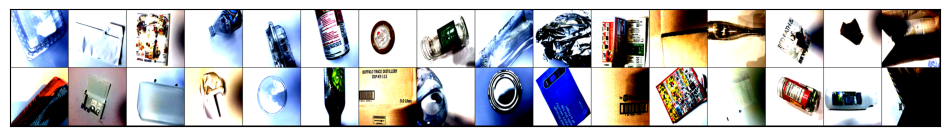

In [ ]:
def display_batch(dl):
    for imgs, lbls in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(torchvision.utils.make_grid(imgs, nrow=16).permute(1,2,0))
        plt.show()
        break

print("Sample batch from training set (with BilateralFilter):")
display_batch(train_loader)

In [ ]:
##########################################
# 5. Define a Simple ResNet50 Model
##########################################
class ResNet50Modified(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Modified, self).__init__()
        self.network = models.resnet50(weights="IMAGENET1K_V2")

        # Replace final FC layers
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Sequential(
            nn.Linear(num_ftrs, 500),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(500, 200),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(200, num_classes)
        )

    def forward(self, x):
        return self.network(x)

def freeze_layers(model, freeze_until=0):
    """
    freeze_until=0 => unfreeze all layers
    freeze_until=6 => freeze more layers
    etc.
    """
    child_counter = 0
    for child in model.network.children():
        child_counter += 1
        if child_counter < freeze_until:
            for param in child.parameters():
                param.requires_grad = False
    return model

In [ ]:
##########################################
# 6. Training & Validation
##########################################
def train_model(epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device):
    history = []
    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_correct = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
            optimizer.step()
            train_losses.append(loss.item())

            _, preds = torch.max(outputs, dim=1)
            train_correct += (preds == labels).sum().item()
            total_train += labels.size(0)

        train_loss_avg = sum(train_losses) / len(train_losses)
        train_acc = train_correct / total_train

        # Validation
        model.eval()
        val_losses = []
        val_correct = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                val_losses.append(val_loss.item())

                _, preds = torch.max(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss_avg = sum(val_losses) / len(val_losses)
        val_acc = val_correct / total_val

        scheduler.step()  # CosineAnnealingLR typically updates each epoch

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss_avg:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.4f}")

        history.append({
            'epoch': epoch+1,
            'train_loss': train_loss_avg,
            'train_acc': train_acc,
            'val_loss': val_loss_avg,
            'val_acc': val_acc
        })
    return history

In [ ]:
##########################################
# 7. Main: Instantiate & Train
##########################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNet50Modified(num_classes=num_classes).to(device)

# Optionally freeze or unfreeze layers
# If your dataset is large, unfreeze all (freeze_until=0).
# If smaller, freeze more (like freeze_until=6).
model = freeze_layers(model, freeze_until=0)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


Epoch 1/20 | Train Loss: 1.4512 | Train Acc: 0.5261 | Val Loss: 0.9731 | Val Acc: 0.7784
Epoch 2/20 | Train Loss: 0.7628 | Train Acc: 0.8644 | Val Loss: 0.7297 | Val Acc: 0.8523
Epoch 3/20 | Train Loss: 0.5800 | Train Acc: 0.9397 | Val Loss: 0.6604 | Val Acc: 0.8693
Epoch 4/20 | Train Loss: 0.4969 | Train Acc: 0.9755 | Val Loss: 0.6028 | Val Acc: 0.9261
Epoch 5/20 | Train Loss: 0.4734 | Train Acc: 0.9893 | Val Loss: 0.5924 | Val Acc: 0.9261
Epoch 6/20 | Train Loss: 0.4566 | Train Acc: 0.9950 | Val Loss: 0.5847 | Val Acc: 0.9375
Epoch 7/20 | Train Loss: 0.4492 | Train Acc: 0.9969 | Val Loss: 0.5811 | Val Acc: 0.9318
Epoch 8/20 | Train Loss: 0.4461 | Train Acc: 0.9969 | Val Loss: 0.6180 | Val Acc: 0.9205
Epoch 9/20 | Train Loss: 0.4436 | Train Acc: 0.9975 | Val Loss: 0.6102 | Val Acc: 0.9205
Epoch 10/20 | Train Loss: 0.4413 | Train Acc: 0.9987 | Val Loss: 0.5888 | Val Acc: 0.9205
Epoch 11/20 | Train Loss: 0.4385 | Train Acc: 0.9981 | Val Loss: 0.5917 | Val Acc: 0.9148
Epoch 12/20 | Train

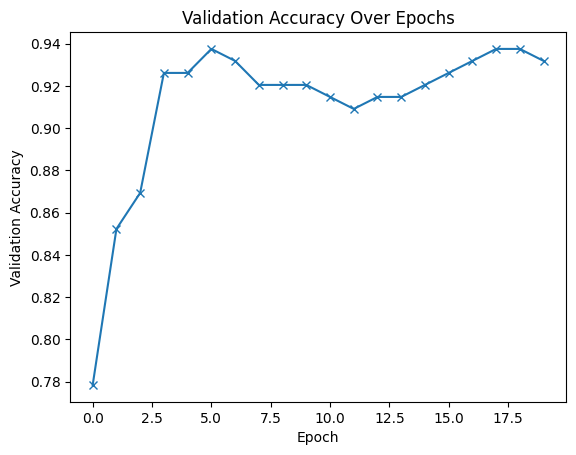

In [ ]:
num_epochs = 20
history = train_model(num_epochs, model, train_loader, val_loader, optimizer, scheduler, criterion, device)

# Plot Accuracy
plt.plot([h['val_acc'] for h in history], '-x')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Over Epochs')
plt.show()

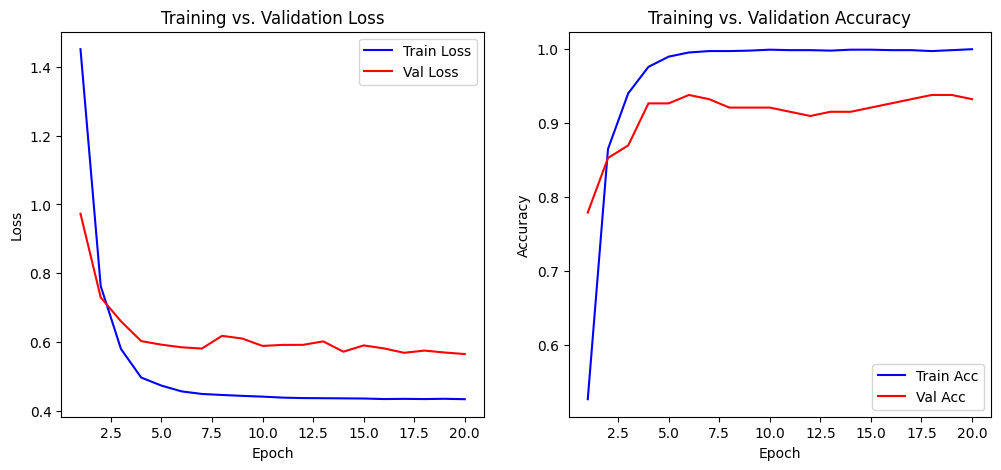

In [ ]:
##########################################
# 7. Plot Training Curves
##########################################
epochs_list = [h['epoch'] for h in history]
train_acc_list = [h['train_acc'] for h in history]
val_acc_list = [h['val_acc'] for h in history]
train_loss_list = [h['train_loss'] for h in history]
val_loss_list = [h['val_loss'] for h in history]

plt.figure(figsize=(12,5))

# Loss curves
plt.subplot(1,2,1)
plt.plot(epochs_list, train_loss_list, 'b-', label='Train Loss')
plt.plot(epochs_list, val_loss_list, 'r-', label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(epochs_list, train_acc_list, 'b-', label='Train Acc')
plt.plot(epochs_list, val_acc_list, 'r-', label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
# After training completes
MODEL_PATH = "resnet50_modified.pth"

# Save only the model's state_dict (recommended best practice)
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")


Model saved to resnet50_modified.pth


In [ ]:
# 8. Evaluate on Test Set
##########################################
model.eval()
test_correct = 0
total_test = 0
preds_list = []
labels_list = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, dim=1)
        test_correct += (preds == labels).sum().item()
        total_test += labels.size(0)

        # Collect for confusion matrix
        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

test_acc = test_correct / total_test
print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.9354


In [ ]:
# For metrics & plots
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


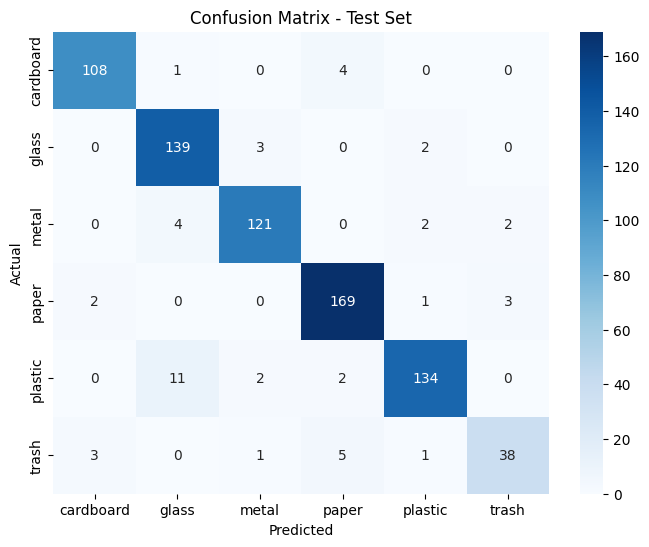

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.96      0.96      0.96       113
       glass       0.90      0.97      0.93       144
       metal       0.95      0.94      0.95       129
       paper       0.94      0.97      0.95       175
     plastic       0.96      0.90      0.93       149
       trash       0.88      0.79      0.84        48

    accuracy                           0.94       758
   macro avg       0.93      0.92      0.92       758
weighted avg       0.94      0.94      0.93       758



In [ ]:
##########################################
# 9. Confusion Matrix & Classification Report
##########################################
cm = confusion_matrix(labels_list, preds_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Classification Report:")
print(classification_report(labels_list, preds_list, target_names=class_names))


In [ ]:
!pip install captum shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
##########################################
# XAI Add-On: Grad-CAM & SHAP
##########################################

import shap
from captum.attr import LayerGradCam
import torch.nn.functional as F
import cv2

In [ ]:

##########################################
# 1. Grad-CAM with Captum
##########################################
# We'll pick the last convolutional layer in layer4
# For ResNet50, often it's layer4[-1].conv3
last_conv_layer = model.network.layer4[-1].conv3

gradcam = LayerGradCam(model, last_conv_layer)

def show_gradcam(model, image, label_idx, class_names):
    """
    Generates Grad-CAM heatmap for a single image & label,
    displays the original & overlay side-by-side.
    """
    model.eval()
    image_batch = image.unsqueeze(0).to(device)
    attributions = gradcam.attribute(image_batch, target=label_idx)

    # Convert attributions to a heatmap
    grad = attributions.squeeze().detach().cpu().numpy()
    grad = np.maximum(grad, 0)
    grad /= (grad.max() + 1e-8)

    # Resize heatmap to match original image
    heatmap = cv2.resize(grad, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Original image to [0..1] range for blending
    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
    img_np = np.uint8(255 * img_np)

    overlay = cv2.addWeighted(img_np, 0.6, heatmap, 0.4, 0)

    # Show images
    fig, ax = plt.subplots(1,2, figsize=(10,5))
    ax[0].imshow(img_np)
    ax[0].set_title(f"Original Image\n(Label: {class_names[label_idx]})")
    ax[0].axis('off')
    ax[1].imshow(overlay)
    ax[1].set_title("Grad-CAM Overlay")
    ax[1].axis('off')
    plt.show()


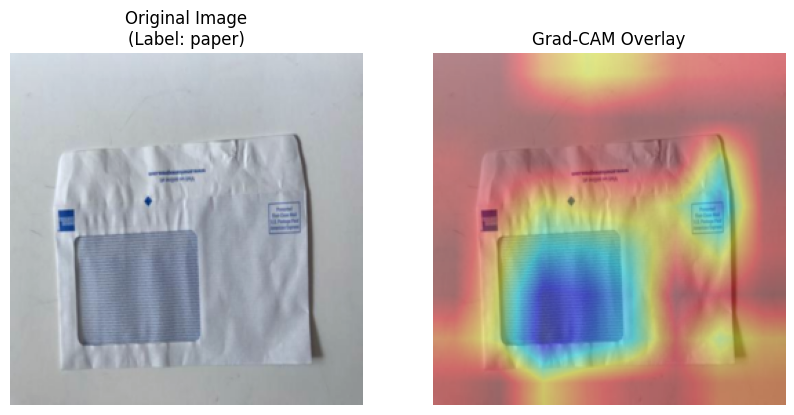

In [ ]:
# Example usage on one batch from test_loader
images, labels = next(iter(test_loader))
sample_img = images[0]
sample_label = labels[0].item()
show_gradcam(model, sample_img, sample_label, class_names)


In [ ]:
def flatten_4d_to_2d(images_np):
    """
    images_np shape: (N, C, H, W)
    returns flattened shape: (N, C*H*W)
    """
    N, C, H, W = images_np.shape
    return images_np.reshape(N, C*H*W)

def unflatten_2d_to_4d(shap_values_2d, N, C, H, W):
    """
    shap_values_2d shape: (N, C*H*W)
    returns shape: (N, C, H, W)
    """
    return shap_values_2d.reshape(N, C, H, W)


In [ ]:
import torch.nn.functional as F

def predict_fn_flat(flat_data_np, model, device, C=3, H=256, W=256):
    """
    flat_data_np: shape (N, C*H*W)
    We unflatten -> (N, C, H, W), run model, return probabilities as numpy array.
    """
    N = flat_data_np.shape[0]
    # Unflatten
    images_4d = flat_data_np.reshape(N, C, H, W)

    # Convert to torch tensor on device
    with torch.no_grad():
        images_t = torch.tensor(images_4d, dtype=torch.float32).to(device)
        outputs = model(images_t)  # logits, shape [N, num_classes]
        probs = F.softmax(outputs, dim=1)  # convert logits to probabilities
        return probs.cpu().numpy()  # back to numpy


In [ ]:
!pip install shap


In [ ]:
# Suppose shap_values is a single Explanation object for one image
# and shap_values.values has shape (256, 256, 3, 6) => (H, W, C, #classes)

class_index = 0  # pick whichever class you want to visualize

# 1) Slice out that class's SHAP values: (H, W, C)
sv_for_class = shap_values.values[..., class_index]

# 2) Also get the image data: shape (256, 256, 3)
# Reshape img_data to (H, W, C) from (1, 2, 256, 256, 3)

# The original selection and reshaping steps are likely where the issue is.
# Assuming shap_values.data is a tensor
img_data = shap_values.data[0]  # Select the first image (from a list?)
# Ensure the image is in the format (C, H, W)
img_data = img_data.permute(1, 2, 0).cpu().numpy()

# 3) Add a batch dimension: now shape is (1, H, W, C)

# Reshape img_data to (H, W, C) and then add a batch dimension
img_data = np.expand_dims(img_data, axis=0)  # Add batch dimension


# Reshape sv_for_class to (H, W, C) and then add a batch dimension
sv_for_class = sv_for_class.transpose(1, 2, 0)  # Reshape to (H, W, C)
sv_for_class = np.expand_dims(sv_for_class, axis=0)  # Add batch dimension


# 4) Now shap.image_plot can handle (N, H, W, C)
shap.image_plot(sv_for_class, img_data)

AttributeError: 'numpy.ndarray' object has no attribute 'permute'